In [ ]:
from google.colab import drive
import os

print("Connecting to Google Drive...")
drive.mount('/content/drive')
print("Drive connected!")

print("Installing required libraries (ultralytics, roboflow, streamlit)...")
# '-q' install ko silent (shaant) rakhta hai
!pip install ultralytics roboflow streamlit -q
print("Libraries installed!")

Connecting to Google Drive...
Mounted at /content/drive
Drive connected!
Installing required libraries (ultralytics, roboflow, streamlit)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.7 MB/s eta 0:00:00
Libraries installed!


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="umBwMWBVGhDHwQrMgdnb")
project = rf.workspace("debugdivas").project("plastic-waste-detection-br9h4")
version = project.version(8)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Plastic-Waste-Detection-8 in yolov8:: 100%|██████████| 14104/14104 [00:02<00:00, 6354.60it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

# 1. SMALL model (yolov8s.pt) ko load karein
model = YOLO("yolov8s.pt")

# 2. Training shuru karein (lekin kam epochs ke saath)
print("Starting FAST training (Small model, 50 epochs)...")
print("All results will be saved safely to your Google Drive.")

results_fast = model.train(
    data="/content/Plastic-Waste-Detection-8/data.yaml",  # Aapka naya (V2) dataset
    epochs=50,       # <-- HUMNE ISE 50 KAR DIYA HAI
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/My_Final_YOLO_Project",  # Aapke Drive mein save hoga
    name="Plastic_Detection_V2_FAST"                        # <-- Naya folder naam
)

print("--- FAST TRAINING COMPLETE! ---")
print("Your new (fast) model is safe in your Google Drive.")

Starting FAST training (Small model, 50 epochs)...
All results will be saved safely to your Google Drive.
Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Plastic-Waste-Detection-8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Plastic_Detectio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


--- Your 'FAST' Model's Test Results ---

This is your 'Results Graph' (Accuracy and Loss):


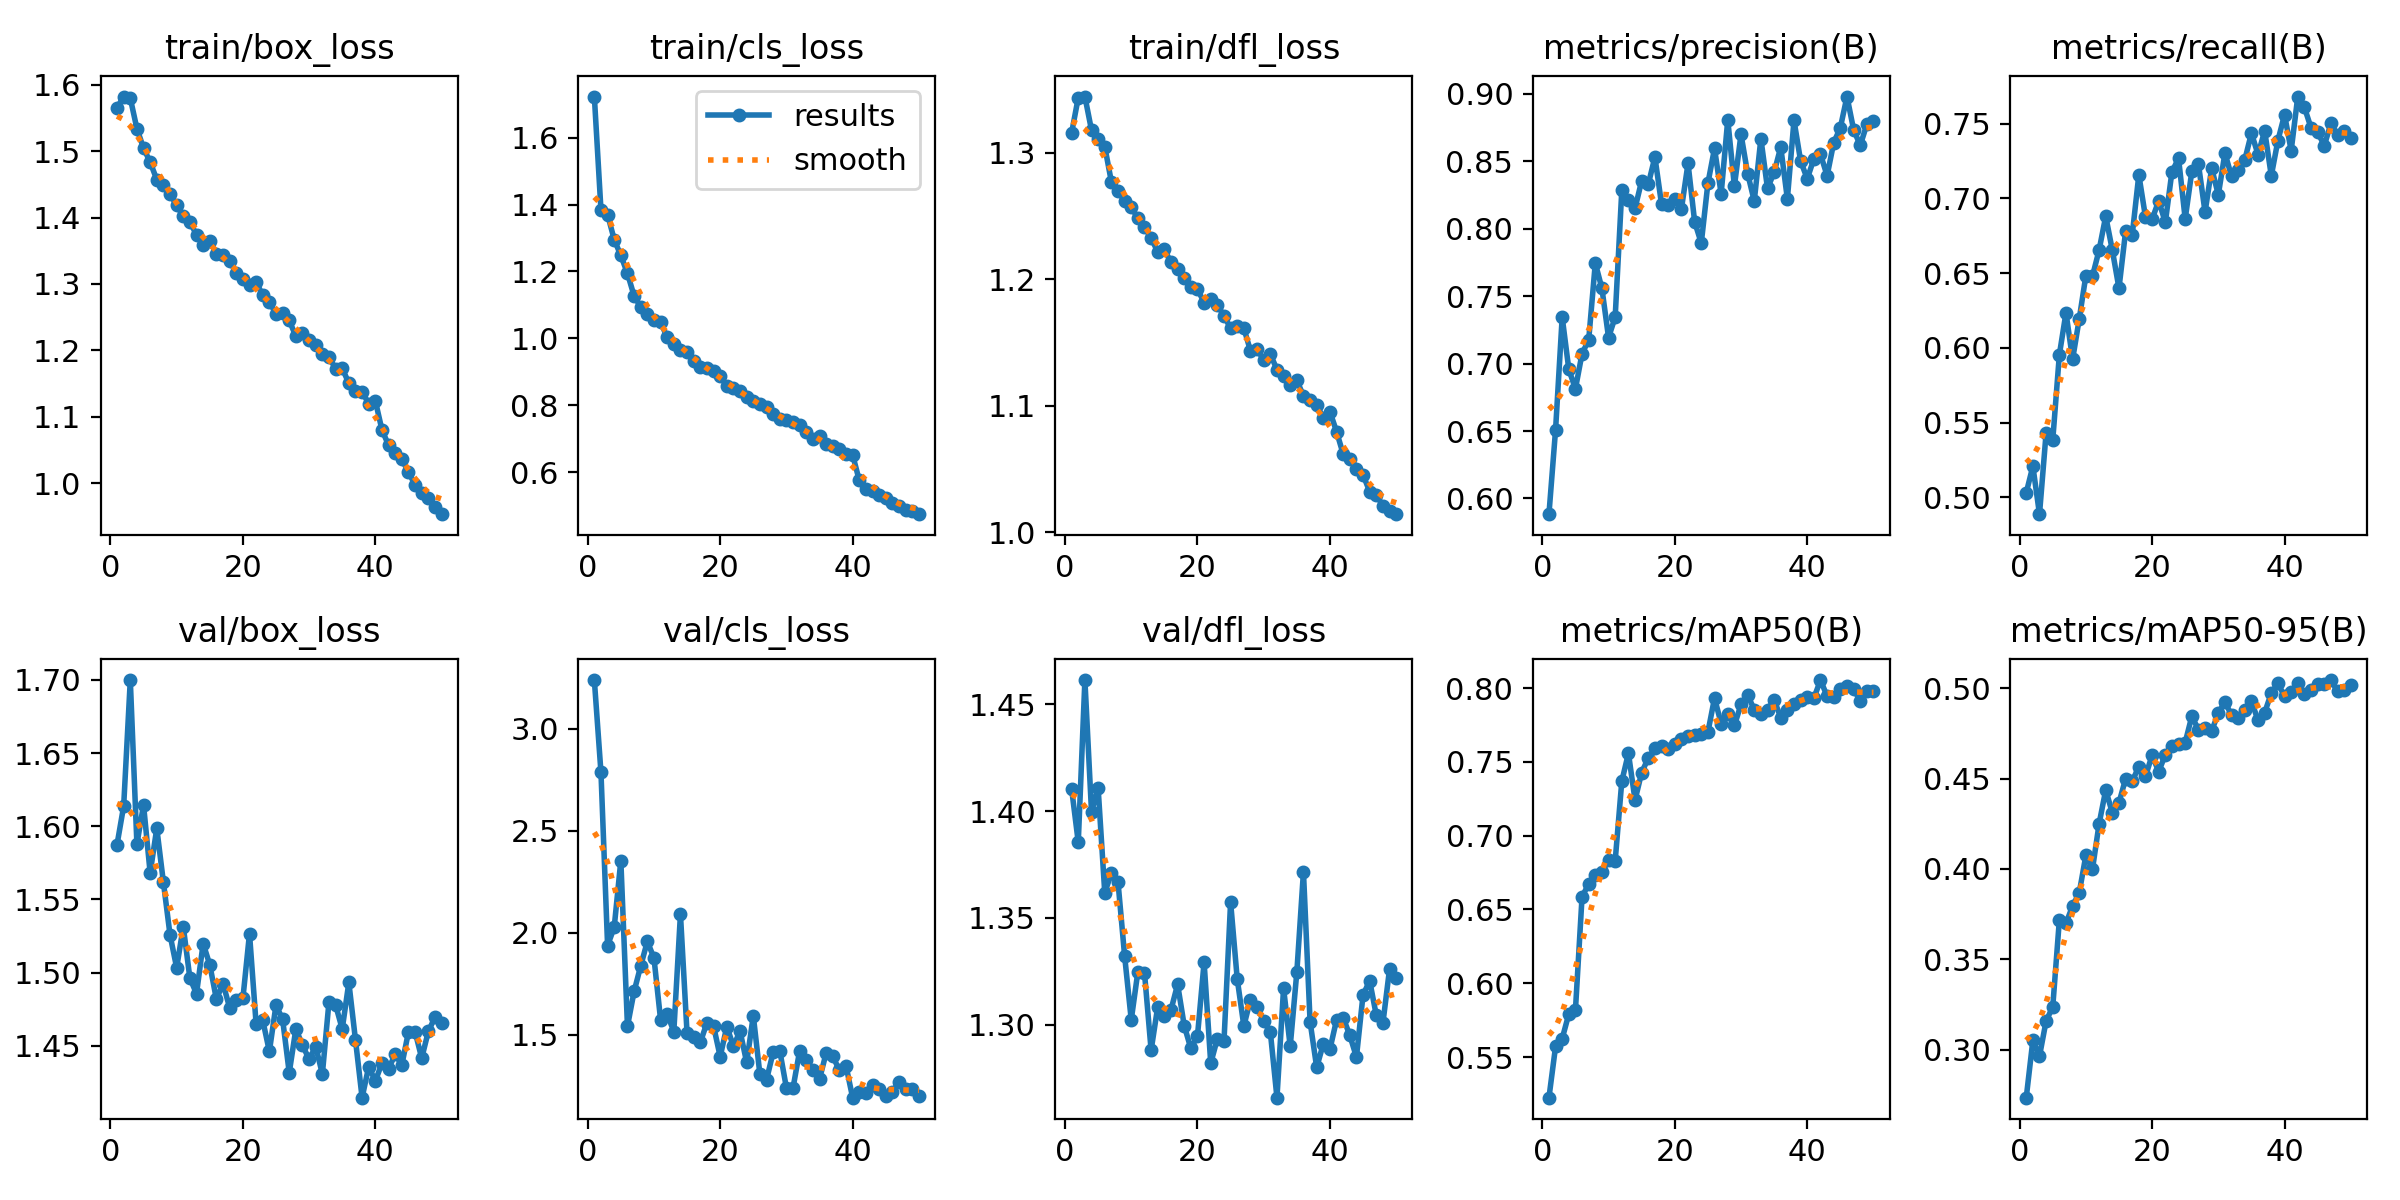



This is your 'Confusion Matrix' (Model's Mistakes):


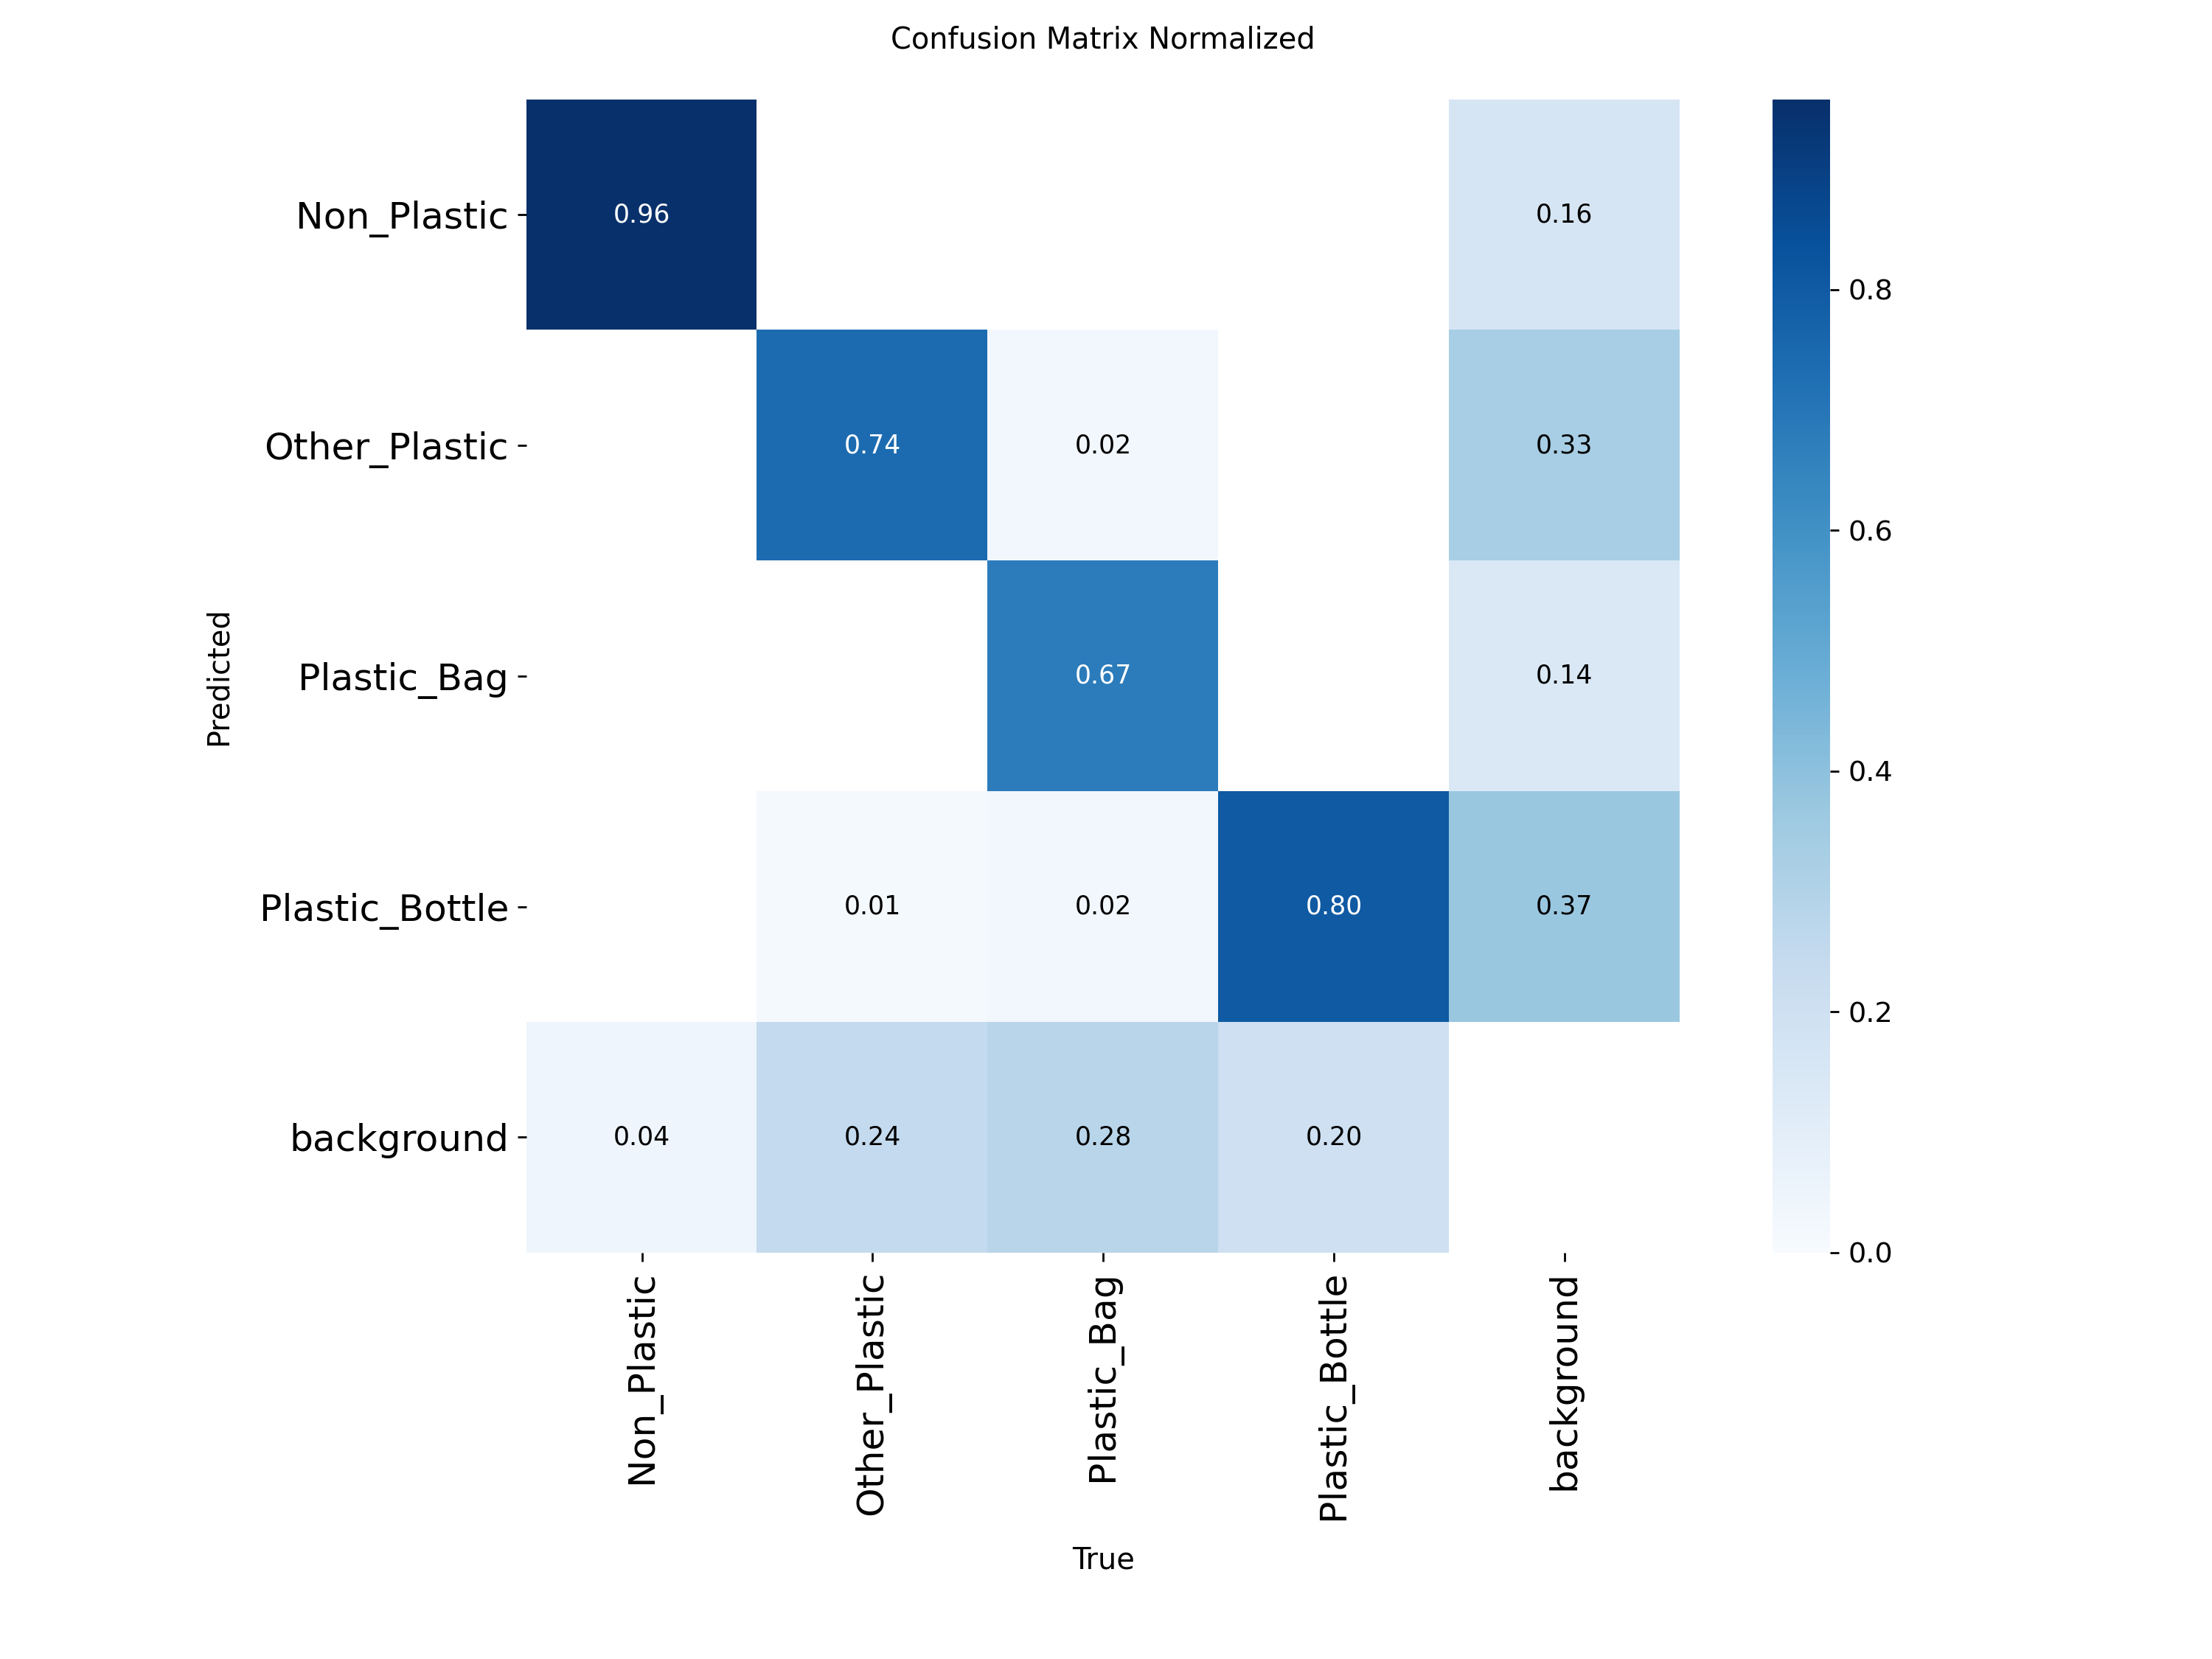

In [ ]:
from IPython.display import Image

# This is the path to your 'FAST' model's results, which are safe in Google Drive
results_path = "/content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST"

print("--- Your 'FAST' Model's Test Results ---")

print("\nThis is your 'Results Graph' (Accuracy and Loss):")
# This shows mAP, precision, recall, and loss over all 50 epochs
display(Image(filename=f"{results_path}/results.png"))

print("\n\nThis is your 'Confusion Matrix' (Model's Mistakes):")
# This shows the percentage of correct and incorrect predictions for each class
display(Image(filename=f"{results_path}/confusion_matrix_normalized.png"))


In [ ]:
print("Installing Gradio and Ultralytics...")
!pip install gradio ultralytics -q
print("Libraries installed!")

Installing Gradio and Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.5 MB/s eta 0:00:00
Libraries installed!


In [ ]:
# --- NAYA STEP 5: App File Banayein (Creative English Version) ---
# Is poore code ko naye cell mein run karein.

%%writefile app.py
import gradio as gr
# Install ultralytics within the script environment
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'])

from ultralytics import YOLO
from PIL import Image
import os

# --- Model Path ---
MODEL_PATH = "/content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST/weights/best.pt"

# --- Model (Load only once) ---
print("Loading AI Model from Google Drive...")
if os.path.exists(MODEL_PATH):
    try:
        model = YOLO(MODEL_PATH)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Model load karne mein error: {e}")
        model = None
else:
    print(f"Error: Model file not found at {MODEL_PATH}")
    model = None

# --- Prediction Function ---
def detect_plastic(uploaded_image):
    if model is None:
        return None # If model didn't load

    results = model.predict(uploaded_image)
    result = results[0]
    annotated_image_bgr = result.plot()
    annotated_image_rgb = annotated_image_bgr[..., ::-1] # BGR to RGB
    final_image = Image.fromarray(annotated_image_rgb)

    return final_image

# --- Article (Neeche dikhne waala text) ---
article_text = """
<div style='text-align: center; font-family: Arial, sans-serif;'>
    <hr>
    <h3>🔍 What This AI Detects</h3>
    <p>This YOLOv8 model was trained on a custom dataset to identify 4 specific categories:</p>
    <ul style='list-style-position: inside; display: inline-block; text-align: left;'>
        <li><b>Plastic_Bottle:</b> Bottles of all shapes and sizes.</li>
        <li><b>Plastic_Bag:</b> Plastic bags, films, and wrappers.</li>
        <li><b>Other_Plastic:</b> Miscellaneous plastic debris (cups, fragments, styrofoam, etc.).</li>
        <li><b>Non_Plastic:</b> Natural debris (wood, leaves, etc.) and clean water patches.</li>
    </ul>
    <p><i>This model's ability to recognize 'Non_Plastic' and clean water helps prevent false detections on clean water surfaces.</i></p>
</div>
"""

# --- Create GUI ---
print("Creating Gradio interface...")
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil", label="Upload Your Image Here"),
    outputs=gr.Image(type="pil", label="Detection Results"),

    # --- Yahaan changes kiye gaye hain ---
    title="🌊 AI Plastic Waste Detector ♻️",  # Naya Title
    description="This AI model detects floating plastic waste in water bodies. Upload an image to see it in action!", # Nayi Description
    article=article_text, # Naya 'Article' section
    theme=gr.themes.Soft() # Nayi 'Creative' Theme
)

# --- Launch the App ---
print("Launching public app... Please wait for the link.")
iface.launch(share=True)

Overwriting app.py


In [ ]:
# --- NAYA STEP 6: App ko Run Karein ---
!python app.py

Loading AI Model from Google Drive...
Error: Model file not found at /content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST/weights/best.pt
Creating Gradio interface...
Launching public app... Please wait for the link.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://51a0b85d80b369911f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2958, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/app.py", line 71, in <module>
    iface.launch(share=True)
  File "/usr/local/lib/python3.12/dist-pa

In [ ]:
# --- STEP 1: Connect Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- STEP 2: Install Libraries ---
print("Installing Gradio and Ultralytics...")
!pip install gradio ultralytics -q
print("Libraries installed!")

Installing Gradio and Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.4 MB/s eta 0:00:00
Libraries installed!


In [ ]:
# --- STEP 3: Create App File ---
%%writefile app.py
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import os

# --- Model Path ---
MODEL_PATH = "/content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST/weights/best.pt"

# --- Model (Load only once) ---
print("Loading AI Model from Google Drive...")
if os.path.exists(MODEL_PATH):
    try:
        model = YOLO(MODEL_PATH)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Model load karne mein error: {e}")
        model = None
else:
    print(f"Error: Model file not found at {MODEL_PATH}")
    model = None

# --- Prediction Function ---
def detect_plastic(uploaded_image):
    if model is None:
        return None

    # --- Yahaan Hum CPU Force Karenge ---
    # Colab mein CPU par chalne ke liye 'cpu=True' likhna achha hai
    results = model.predict(uploaded_image, cpu=True)

    result = results[0]
    annotated_image_bgr = result.plot()
    annotated_image_rgb = annotated_image_bgr[..., ::-1] # BGR to RGB
    final_image = Image.fromarray(annotated_image_rgb)

    return final_image

# --- Create GUI ---
print("Creating Gradio interface...")
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil", label="Upload Your Image Here"),
    outputs=gr.Image(type="pil", label="Detection Results"),

    title="🌊 AI Plastic Waste Detector ♻️",
    description="This AI model detects floating plastic waste in water bodies. Upload an image to see it in action!",
    article="""
    <div style='text-align: center; font-family: Arial, sans-serif;'>
        <hr>
        <h3>🔍 What This AI Detects</h3>
        <p>This YOLOv8 model was trained on a custom dataset to identify 4 specific categories:</p>
        <ul style='list-style-position: inside; display: inline-block; text-align: left;'>
            <li><b>Plastic_Bottle:</b> Bottles of all shapes and sizes.</li>
            <li><b>Plastic_Bag:</b> Plastic bags, films, and wrappers.</li>
            <li><b>Other_Plastic:</b> Miscellaneous plastic debris (cups, fragments, styrofoam, etc.).</li>
            <li><b>Non_Plastic:</b> Natural debris (wood, leaves, etc.) and clean water patches.</li>
        </ul>
    </div>
    """,
    theme=gr.themes.Soft()
)

# --- Launch the App ---
print("Launching public app... Please wait for the link.")
iface.launch(share=True)

Writing app.py


In [ ]:
# --- STEP 4: Run The App ---
!python app.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading AI Model from Google Drive...
Model loaded successfully.
Creating Gradio interface...
Launching public app... Please wait for the link.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6b395910c444265918.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
print("Installing Gradio and Ultralytics...")
!pip install gradio ultralytics -q
print("Libraries installed!")

Installing Gradio and Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.9 MB/s eta 0:00:00
Libraries installed!


In [ ]:
%%writefile app.py
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import os

# --- Model Path (Aapka 'FAST' model) ---
MODEL_PATH = "/content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST/weights/best.pt"

# --- Model (Sirf ek baar load karein) ---
print("Loading AI Model from Google Drive...")
if os.path.exists(MODEL_PATH):
    try:
        model = YOLO(MODEL_PATH)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Model load karne mein error: {e}")
        model = None
else:
    print(f"Error: Model file not found at {MODEL_PATH}")
    model = None

# --- Prediction Function ---
def detect_plastic(uploaded_image):
    if model is None:
        return None

    # Is baar yeh GPU use karega (default)
    results = model.predict(uploaded_image)

    result = results[0]
    annotated_image_bgr = result.plot()
    annotated_image_rgb = annotated_image_bgr[..., ::-1] # BGR to RGB
    final_image = Image.fromarray(annotated_image_rgb)

    return final_image

# --- Create GUI ---
print("Creating Gradio interface...")
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil", label="Upload Your Image Here"),
    outputs=gr.Image(type="pil", label="Detection Results"),

    title="🌊 AI Plastic Waste Detector ♻️",
    description="This AI model detects floating plastic waste in water bodies. Upload an image to see it in action!",
    article="""
    <div style='text-align: center; font-family: Arial, sans-serif;'>
        <hr>
        <h3>🔍 What This AI Detects</h3>
        <p>This YOLOv8 model was trained on a custom dataset to identify 4 specific categories:</p>
        <ul style='list-style-position: inside; display: inline-block; text-align: left;'>
            <li><b>Plastic_Bottle:</b> Bottles of all shapes and sizes.</li>
            <li><b>Plastic_Bag:</b> Plastic bags, films, and wrappers.</li>
            <li><b>Other_Plastic:</b> Miscellaneous plastic debris (cups, fragments, styrofoam, etc.).</li>
            <li><b>Non_Plastic:</b> Natural debris (wood, leaves, etc.) and clean water patches.</li>
        </ul>
    </div>
    """,
    theme=gr.themes.Soft()
)

# --- Launch the App ---
print("Launching public app... Please wait for the link.")
iface.launch(share=True)

Writing app.py


In [ ]:
!python app.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading AI Model from Google Drive...
Model loaded successfully.
Creating Gradio interface...
Launching public app... Please wait for the link.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8d054d7c9e6d849c8a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)

0: 640x640 1 Non_Plastic, 2 Other_Plastics, 1 Plastic_Bag, 3 Plastic_Bottles, 843.1ms
Speed: 44.6ms preprocess, 843.1ms inference, 31.6ms postprocess per image at shape (1, 3, 640, 640)

0: 480x640 1 Plastic_Bag, 485.1ms
Spe

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Installing Gradio and Ultralytics...")
!pip install gradio ultralytics -q
print("Libraries installed!")

Installing Gradio and Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.8 MB/s eta 0:00:00
Libraries installed!


In [ ]:
%%writefile app.py
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import os

# --- Model Path (Aapka 'FAST' model) ---
MODEL_PATH = "/content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST/weights/best.pt"

# --- Model (Sirf ek baar load karein) ---
print("Loading AI Model from Google Drive...")
if os.path.exists(MODEL_PATH):
    try:
        model = YOLO(MODEL_PATH)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Model load karne mein error: {e}")
        model = None
else:
    print(f"Error: Model file not found at {MODEL_PATH}")
    model = None

# --- Prediction Function ---
def detect_plastic(uploaded_image):
    if model is None:
        return None

    # Is baar yeh GPU use karega (default)
    results = model.predict(uploaded_image)

    result = results[0]
    annotated_image_bgr = result.plot()
    annotated_image_rgb = annotated_image_bgr[..., ::-1] # BGR to RGB
    final_image = Image.fromarray(annotated_image_rgb)

    return final_image

# --- Create GUI ---
print("Creating Gradio interface...")
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil", label="Upload Your Image Here"),
    outputs=gr.Image(type="pil", label="Detection Results"),

    title="🌊 AI Plastic Waste Detector ♻️",
    description="This AI model detects floating plastic waste in water bodies. Upload an image to see it in action!",
    article="""
    <div style='text-align: center; font-family: Arial, sans-serif;'>
        <hr>
        <h3>🔍 What This AI Detects</h3>
        <p>This YOLOv8 model was trained on a custom dataset to identify 4 specific categories:</p>
        <ul style='list-style-position: inside; display: inline-block; text-align: left;'>
            <li><b>Plastic_Bottle:</b> Bottles of all shapes and sizes.</li>
            <li><b>Plastic_Bag:</b> Plastic bags, films, and wrappers.</li>
            <li><b>Other_Plastic:</b> Miscellaneous plastic debris (cups, fragments, styrofoam, etc.).</li>
            <li><b>Non_Plastic:</b> Natural debris (wood, leaves, etc.) and clean water patches.</li>
        </ul>
    </div>
    """,
    theme=gr.themes.Soft()
)

# --- Launch the App ---
print("Launching public app... Please wait for the link.")
iface.launch(share=True)

Writing app.py


In [ ]:
!python app.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading AI Model from Google Drive...
Model loaded successfully.
Creating Gradio interface...
Launching public app... Please wait for the link.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://551b605f377376ffa6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)

0: 384x640 3 Plastic_Bottles, 50.4ms
Speed: 25.5ms preprocess, 50.4ms inference, 3.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 Plastic_Bottles, 10.9ms
Speed: 2.7ms preprocess, 10.9ms inference, 3.4ms po

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Installing Gradio and Ultralytics...")
!pip install gradio ultralytics -q
print("Libraries installed!")

Installing Gradio and Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.9 MB/s eta 0:00:00
Libraries installed!


In [ ]:
%%writefile app.py
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import os

# --- Model Path (Aapka 'FAST' model) ---
MODEL_PATH = "/content/drive/MyDrive/My_Final_YOLO_Project/Plastic_Detection_V2_FAST/weights/best.pt"

# --- Model (Sirf ek baar load karein) ---
print("Loading AI Model from Google Drive...")
if os.path.exists(MODEL_PATH):
    try:
        model = YOLO(MODEL_PATH)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Model load karne mein error: {e}")
        model = None
else:
    print(f"Error: Model file not found at {MODEL_PATH}")
    model = None

# --- Prediction Function ---
def detect_plastic(uploaded_image):
    if model is None:
        return None

    # Is baar yeh GPU use karega (default)
    results = model.predict(uploaded_image)

    result = results[0]
    annotated_image_bgr = result.plot()
    annotated_image_rgb = annotated_image_bgr[..., ::-1] # BGR to RGB
    final_image = Image.fromarray(annotated_image_rgb)

    return final_image

# --- Create GUI ---
print("Creating Gradio interface...")
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil", label="Upload Your Image Here"),
    outputs=gr.Image(type="pil", label="Detection Results"),

    title="🌊 AI Plastic Waste Detector ♻️",
    description="This AI model detects floating plastic waste in water bodies. Upload an image to see it in action!",
    article="""
    <div style='text-align: center; font-family: Arial, sans-serif;'>
        <hr>
        <h3>🔍 What This AI Detects</h3>
        <p>This YOLOv8 model was trained on a custom dataset to identify 4 specific categories:</p>
        <ul style='list-style-position: inside; display: inline-block; text-align: left;'>
            <li><b>Plastic_Bottle:</b> Bottles of all shapes and sizes.</li>
            <li><b>Plastic_Bag:</b> Plastic bags, films, and wrappers.</li>
            <li><b>Other_Plastic:</b> Miscellaneous plastic debris (cups, fragments, styrofoam, etc.).</li>
            <li><b>Non_Plastic:</b> Natural debris (wood, leaves, etc.) and clean water patches.</li>
        </ul>
    </div>
    """,
    theme=gr.themes.Soft()
)

# --- Launch the App ---
print("Launching public app... Please wait for the link.")
iface.launch(share=True)

Writing app.py


In [ ]:
!python app.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading AI Model from Google Drive...
Model loaded successfully.
Creating Gradio interface...
Launching public app... Please wait for the link.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://41f754beeef1e8864c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)

0: 384x640 5 Plastic_Bottles, 50.5ms
Speed: 47.9ms preprocess, 50.5ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)

0: 448x640 4 Plastic_Bags, 73.1ms
Speed: 3.5ms preprocess, 73.1ms inference, 3.8ms postp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Installing Gradio and Ultralytics...")
!pip install gradio ultralytics -q
print("Libraries installed!")

Installing Gradio and Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.3 MB/s eta 0:00:00
Libraries installed!


In [ ]:
#%%writefile app.py
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import os

# --- Model Path (Aapka 'FAST' model) ---
MODEL_PATH = "/content/best (1).pt"

# --- Model (Sirf ek baar load karein) ---
print("Loading AI Model from Google Drive...")
if os.path.exists(MODEL_PATH):
    try:
        model = YOLO(MODEL_PATH)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Model load karne mein error: {e}")
        model = None
else:
    print(f"Error: Model file not found at {MODEL_PATH}")
    model = None

# --- Prediction Function ---
def detect_plastic(uploaded_image):
    if model is None:
        return None

    # Is baar yeh GPU use karega (default)
    results = model.predict(uploaded_image)

    result = results[0]
    annotated_image_bgr = result.plot()
    annotated_image_rgb = annotated_image_bgr[..., ::-1] # BGR to RGB
    final_image = Image.fromarray(annotated_image_rgb)

    return final_image

# --- Create GUI ---
print("Creating Gradio interface...")
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil", label="Upload Your Image Here"),
    outputs=gr.Image(type="pil", label="Detection Results"),

    title="🌊 AI Plastic Waste Detector ♻️",
    description="This AI model detects floating plastic waste in water bodies. Upload an image to see it in action!",
    article="""
    <div style='text-align: center; font-family: Arial, sans-serif;'>
        <hr>
        <h3>🔍 What This AI Detects</h3>
        <p>This YOLOv8 model was trained on a custom dataset to identify 4 specific categories:</p>
        <ul style='list-style-position: inside; display: inline-block; text-align: left;'>
            <li><b>Plastic_Bottle:</b> Bottles of all shapes and sizes.</li>
            <li><b>Plastic_Bag:</b> Plastic bags, films, and wrappers.</li>
            <li><b>Other_Plastic:</b> Miscellaneous plastic debris (cups, fragments, styrofoam, etc.).</li>
            <li><b>Non_Plastic:</b> Natural debris (wood, leaves, etc.) and clean water patches.</li>
        </ul>
    </div>
    """,
    theme=gr.themes.Soft()
)

# --- Launch the App ---
print("Launching public app... Please wait for the link.")
iface.launch(
    share=True,
    debug=True,
    inbrowser=True
)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:





















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































!python app.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading AI Model from Google Drive...
Model loaded successfully.
Creating Gradio interface...
Launching public app... Please wait for the link.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://7c4cb8a2447df93f87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)

0: 384x640 2 Other_Plastics, 1 Plastic_Bottle, 75.5ms
Speed: 8.2ms preprocess, 75.5ms inference, 48.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 Plastic_Bottles, 10.9ms
Speed: 2.5ms preprocess, 10.9ms in

In [ ]:
import gradio as gr

def greet(name):
    return f"Hello {name}"

demo = gr.Interface(
    fn=greet,
    inputs="text",
    outputs="text"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6bf32d619bbc177d06.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install ultralytics gradio pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.6 MB/s eta 0:00:00


In [ ]:
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
MODEL_PATH = "/content/best (1).pt"

model = YOLO(MODEL_PATH)
print("Model loaded successfully")

Model loaded successfully


In [ ]:
def detect_plastic(uploaded_image):

    results = model.predict(uploaded_image)

    result = results[0]

    annotated_image_bgr = result.plot()

    annotated_image_rgb = annotated_image_bgr[..., ::-1]

    return Image.fromarray(annotated_image_rgb)

In [ ]:
iface = gr.Interface(
    fn=detect_plastic,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="pil"),
    title="Plastic Waste Detector"
)

In [ ]:
iface.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4b1d2e742ab265e72d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



0: 384x640 3 Plastic_Bottles, 54.7ms
Speed: 21.6ms preprocess, 54.7ms inference, 46.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Plastic_Bottle, 11.0ms
Speed: 4.1ms preprocess, 11.0ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Plastic_Bag, 1 Plastic_Bottle, 11.1ms
Speed: 2.5ms preprocess, 11.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
Created dataset file at: .gradio/flagged/dataset2.csv
